# Multiscale simulation: prediction results

Run this notebook from the study folder using an **R kernel**.
The prediction sections read completed files from `output/raw/` and require `ggplot2`.
Generate those files with `R/run_job.R`, or copy the cluster `output/` folder here.

Edit the settings below and run the prediction cells in order. The final **SMC diagnostics**
section is separate: it runs WN twice at saved parameter estimates and also needs
`ResTree` and `patchwork`. Its sample size and dimension are set in that section.


In [1]:
library(ggplot2)

# Data and methods to show, in panel order.
study_root <- "."  # Folder containing output/.
output_dir <- file.path(study_root, "output", "raw")
n_select <- 10000L
d_select <- 10L
methods_to_plot <- c(
  "BART", "sSGV", "ResTGP(Full)", "ResTGP(PP)",
  "ResTGP(WN)", "ResTGP(WN, PMMH)"
)

# Plot settings.
target <- "observed"  # "observed" response 
quantity <- "sd"      # "sd" or "variance"
n_bins <- 20L
facet_columns <- 3L
scatter_size <- 0.8
scatter_alpha <- 0.35
line_width <- 0.65
figure_width <- 12
figure_height <- 8
options(repr.plot.width = figure_width, repr.plot.height = figure_height)

# Local figure export.
export_figures <- TRUE
figure_dir <- file.path(study_root, "figures")


## Labels and appearance


In [2]:
method_labels <- c(
  BART = "BART",
  Vecchia = "sSGV",
  Full = "ResTGP(Full)",
  PP_middle = "ResTGP(PP)",
  WN = "ResTGP(WN)",
  WN_PMMH = "ResTGP(WN, PMMH)"
)

method_linetypes <- c(
  "BART" = "dashed", "sSGV" = "dotted",
  "ResTGP(Full)" = "solid", "ResTGP(PP)" = "longdash",
  "ResTGP(WN)" = "dotdash", "ResTGP(WN, PMMH)" = "1343"
)

plot_style <- list(
  theme_bw(base_size = 14),
  theme(legend.position = "none")
)


## Load completed results

The loop below loads one completed file at a time. `metrics` holds the selected
methods across all sample sizes and dimensions; `selected` holds predictions
for `n_select` and `d_select`. Backups and unfinished runs are ignored.


In [3]:
files <- list.files(output_dir, pattern = "^result[.]rds$",
                    recursive = TRUE, full.names = TRUE)
columns <- c(
  "n", "d", "method_label", "RMSE", "CRPS_Gaussian", "NLPD_Gaussian",
  "coverage95_Gaussian", "total_minutes"
)
metric_tables <- list()
prediction_tables <- list()
results <- list()

for (file in files) {
  result <- readRDS(file)
  method <- as.character(result$metrics$method)
  label <- unname(method_labels[method])
  if (!label %in% methods_to_plot) next

  # Keep the same columns when combining results from different runs.
  row <- result$metrics
  row$method_label <- label
  row$total_minutes <- row$total_seconds / 60
  metric_tables[[length(metric_tables) + 1L]] <- row[columns]

  if (row$n == n_select && row$d == d_select) {
    results[[method]] <- result
    prediction_tables[[method]] <- data.frame(method = method, result$predictions)
  }
}
if (!length(results)) stop("No completed results match the selected n, d and methods.")

metrics <- do.call(rbind, metric_tables)
metrics$method_label <- factor(metrics$method_label, levels = methods_to_plot)
metrics <- metrics[order(metrics$n, metrics$d, metrics$method_label), ]
selected <- do.call(rbind, prediction_tables)
selected$method_label <- factor(method_labels[selected$method], levels = methods_to_plot)

# A zero count means this method has no completed result for the selected case.
print(table(selected$method_label))



            BART             sSGV     ResTGP(Full)       ResTGP(PP)       ResTGP(WN) 
            2000             2000             2000             2000             2000 
ResTGP(WN, PMMH) 
            2000 


## Accuracy and fitting diagnostics

This table includes all available **sample sizes and dimensions** for the selected methods. Times are in **minutes**. Gaussian scores and coverage use the predictive mean
and variance; coverage is computed over all held-out observations.

Inspect a selected fit with, for example, `results[["PP_middle"]]$diagnostics`.


In [4]:
print(metrics, row.names = FALSE, digits = 4)


     n  d     method_label   RMSE CRPS_Gaussian NLPD_Gaussian coverage95_Gaussian
 10000 10             BART 0.9847        0.5462         1.400              0.9430
 10000 10             sSGV 1.1220        0.6216         1.526              0.9510
 10000 10     ResTGP(Full) 0.9634        0.5276         1.374              0.9435
 10000 10       ResTGP(PP) 0.8058        0.4387         1.201              0.9370
 10000 10       ResTGP(WN) 0.9130        0.4740         1.480              0.9265
 10000 10 ResTGP(WN, PMMH) 0.8573        0.4423         1.080              0.9645
 10000 20             BART 1.0353        0.5754         1.452              0.9485
 10000 20             sSGV 1.3278        0.7407         1.691              0.9480
 10000 20     ResTGP(Full) 0.9309        0.5107         1.341              0.9355
 10000 20       ResTGP(PP) 0.8740        0.4814         1.280              0.9355
 10000 20       ResTGP(WN) 0.9517        0.5022         1.379              0.9365
 10000 20 ResTGP

## Timing

For **n_select**, show fitting and prediction time for the selected methods
across dimensions. All values are minutes and use the original inputs.


In [5]:
timing <- subset(metrics, n == n_select,
                 select = c("method_label", "d", "total_minutes"))
timing <- timing[order(timing$d, timing$method_label), ]
print(timing, row.names = FALSE, digits = 4)


     method_label  d total_minutes
             BART 10        65.643
             sSGV 10         1.176
     ResTGP(Full) 10         6.698
       ResTGP(PP) 10         9.843
       ResTGP(WN) 10         8.438
 ResTGP(WN, PMMH) 10       904.562
             BART 20       112.899
             sSGV 20         3.225
     ResTGP(Full) 20         8.100
       ResTGP(PP) 20        17.697
       ResTGP(WN) 20        23.335
 ResTGP(WN, PMMH) 20       770.871


## Predictive means

Each point is one held-out input. All panels share axis limits, and the diagonal
shows perfect agreement. Set `target = "truth"` to compare against the noise-free signal.


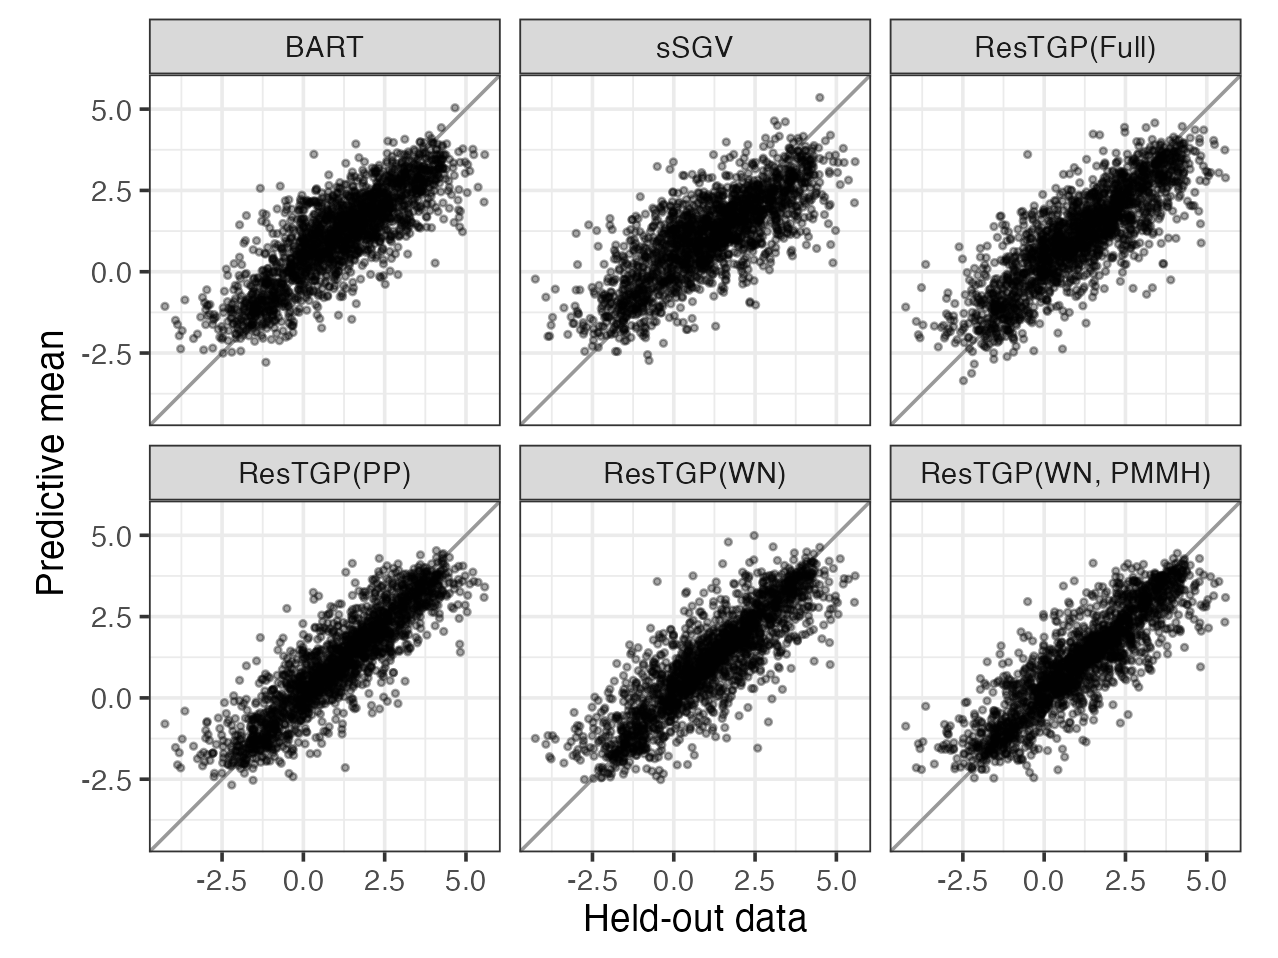

In [6]:
scatter_data <- selected
scatter_data$target <- scatter_data[[target]]
limits <- range(scatter_data$target, scatter_data$mean, finite = TRUE)
x_label <- if (target == "truth") "True signal" else "Held-out data"

p_scatter <- ggplot(scatter_data, aes(target, mean)) +
  geom_abline(slope = 1, intercept = 0, colour = "grey60") +
  geom_point(size = scatter_size, alpha = scatter_alpha) +
  facet_wrap(~method_label, ncol = facet_columns) +
  coord_equal(xlim = limits, ylim = limits) +
  labs(x = x_label, y = "Predictive mean") +
  plot_style
print(p_scatter)


## Predictive uncertainty across inputs

The simulated noise varies with **x2**. Grey points show the response predictive
standard deviation (or variance) at individual held-out inputs. Black lines and
crosses show averages within x2 bins. The solid grey curve is the true noise alone;
it excludes uncertainty about the mean signal. Every held-out input contributes.


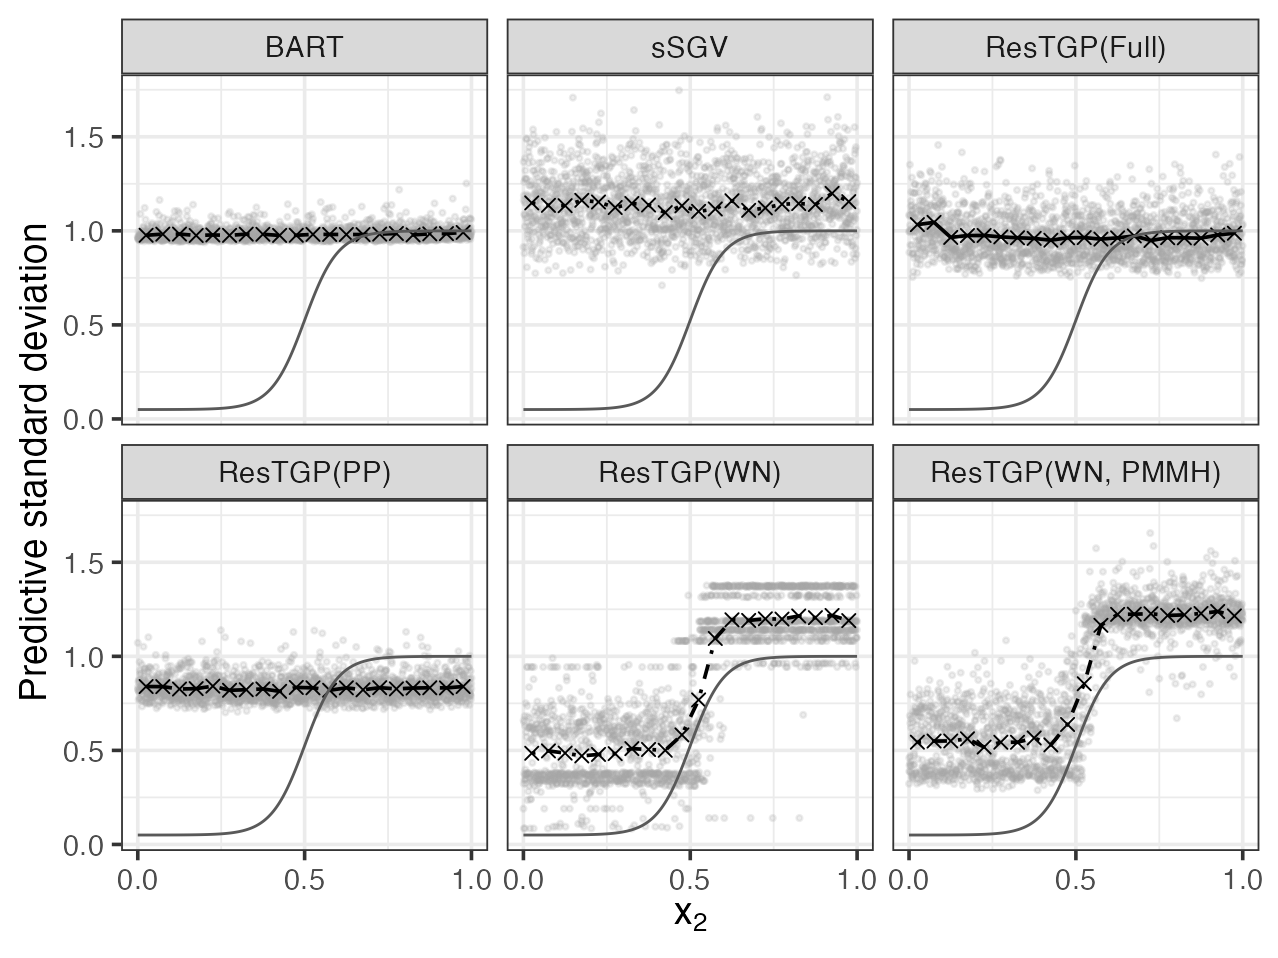

In [7]:
uncertainty_data <- selected
power <- if (quantity == "variance") 2 else 1
uncertainty_data$uncertainty <- uncertainty_data$sd^power
uncertainty_data$bin <- cut(uncertainty_data$x2, breaks = seq(0, 1, length.out = n_bins + 1L),
             include.lowest = TRUE)
binned <- aggregate(cbind(x2, uncertainty) ~ method_label + bin, data = uncertainty_data, FUN = mean)

# Every method uses the same test inputs and simulated noise.
noise_reference <- uncertainty_data[!duplicated(uncertainty_data$test_id), c("x2", "noise_sd")]
noise_reference$uncertainty <- noise_reference$noise_sd^power

y_label <- if (quantity == "variance") "Predictive variance" else "Predictive standard deviation"

p_inputs <- ggplot(uncertainty_data, aes(x2, uncertainty)) +
  geom_point(colour = "grey65", alpha = 0.2, size = 0.6) +
  geom_line(data = binned, aes(linetype = method_label), linewidth = line_width) +
  geom_point(data = binned, shape = 4, size = 2, stroke = 0.5) +
  geom_line(data = noise_reference, colour = "grey35",
            linetype = "solid", linewidth = 0.5) +
  facet_wrap(~method_label, ncol = facet_columns) +
  scale_x_continuous(breaks = c(0, 0.5, 1)) +
  scale_linetype_manual(values = method_linetypes) +
  labs(x = expression(x[2]), y = y_label) +
  plot_style
print(p_inputs)


## Local PDF export

`export_figures` controls these two prediction figures. The filenames are `HD_n_10k_d10_scatterplot.pdf` and `HD_n_10k_d10_predictive_SE.pdf` for the
default selection. The latter shows response predictive standard deviation by default.
Both PDFs are 8 by 6 inches.


In [8]:
if (export_figures) {
  dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)

  n_label <- paste0(n_select / 1000, "k")
  prefix <- file.path(figure_dir, paste0("HD_n_", n_label, "_d", d_select))

  ggsave(paste0(prefix, "_scatterplot.pdf"),
         p_scatter, width = 8, height = 6)

  ggsave(paste0(prefix, "_predictive_SE.pdf"),
         p_inputs, width = 8, height = 6)
}


## SMC diagnostics at the saved WN estimates

This section reruns SMC without re-estimating covariance parameters. It uses the
original training inputs for **n = 10,000, d = 20**, independently of the prediction
selection above. 



### SMC with d=20

In [9]:
Sys.setenv(OMP_NUM_THREADS = "1")

In [10]:
library(ResTree)
library(patchwork)

smc_n <- 10000
smc_d <- 20
smc_seed_offset <- 10000
smc_figure_file <- file.path(figure_dir, paste0("SMC_diagnostics_n10k_d", smc_d, ".pdf"))

input_dir <- file.path(output_dir,
                       sprintf("n%d_d%d", smc_n, smc_d), "WN")
saved <- readRDS(file.path(input_dir, "result.rds"))
dat <- readRDS(file.path(input_dir, "data.rds"))
settings <- saved$settings
parameters <- saved$diagnostics$theta



#########################################################
## ResTree: Residual Tree Gaussian Process Models for High-Dimensional Spatial Data
## Copyright (C) 2024-2026 by Pulong Ma <plma@iastate.edu>
## Please cite ResTree including its version number: citation("ResTree").
##########################################################


In [11]:
X <- dat$X
y <- dat$y - saved$y_center

theta <- restree_theta(
  sig2   = parameters$sig2,
  range  = parameters$range,
  nugget = parameters$nugget,
  nu     = parameters$nu,
  family = parameters$family,
  form   = parameters$form
)

model <- restree_model(
  X, y,
  depth = settings$depth,
  r = settings$r,
  leaf_model = "WN",
  design = saved$diagnostics$design,
  cut_method = "uniform",
  prior_rho = settings$prior_rho,
  prior_beta = settings$prior_beta,
  seed = settings$seed 
)


In [12]:
  smc_fits <- restree_fit(
    model, theta, method = "smc",
    seed = settings$seed+24, nparticles=1600,
    resampling = "stratified", temper_alpha = 0.1
  )

fit = smc_fits

### ESS and cumulative log evidence

The package records these diagnostics at tree-level ends. Red crosses mark levels
where resampling occurred; ESS is shown **before** resampling. Cumulative logZ
includes the initial root contribution. These plots do not assume node-step logging.


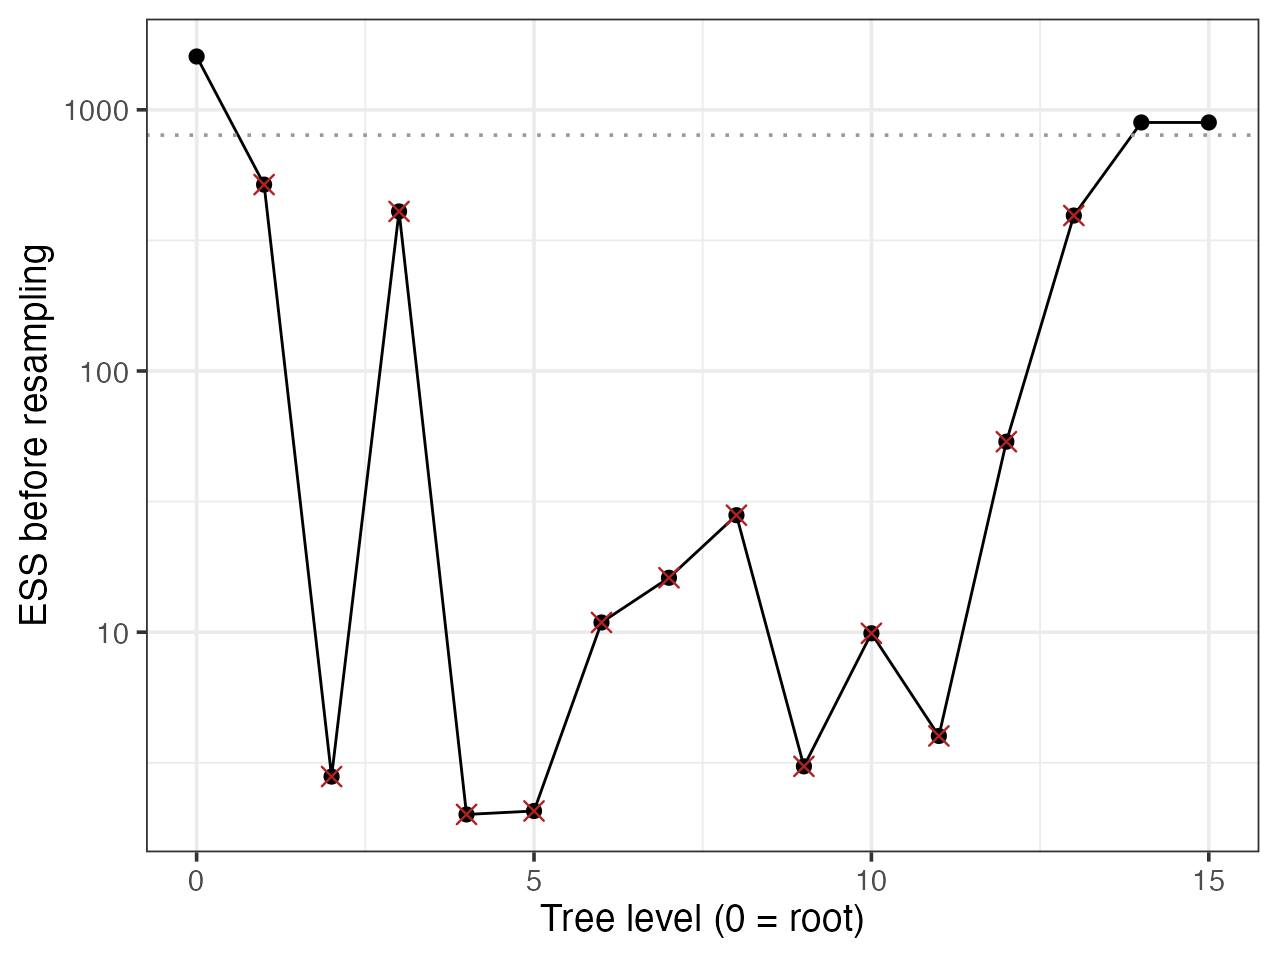

In [13]:
trace <- restree_diagnostics(fit, type = "trace")
levels <- trace$levels
levels$logZ <- as.numeric(fit$fit$Phi0) + cumsum(levels$logZ_increment)
events <- subset(levels, resampled == 1)

p_ess <- ggplot(levels, aes(level, ess)) +
  geom_line(linewidth = 0.5) +
  geom_point(size = 2) +
  geom_point(data = events, colour = "firebrick", shape = 4, size = 3) +
  geom_hline(yintercept = fit$nparticles / 2,
             colour = "grey60", linetype = "dotted") +
  scale_y_log10() +
  labs(x = "Tree level (0 = root)", y = "ESS before resampling") +
  theme_bw(base_size = 14)
print(p_ess)


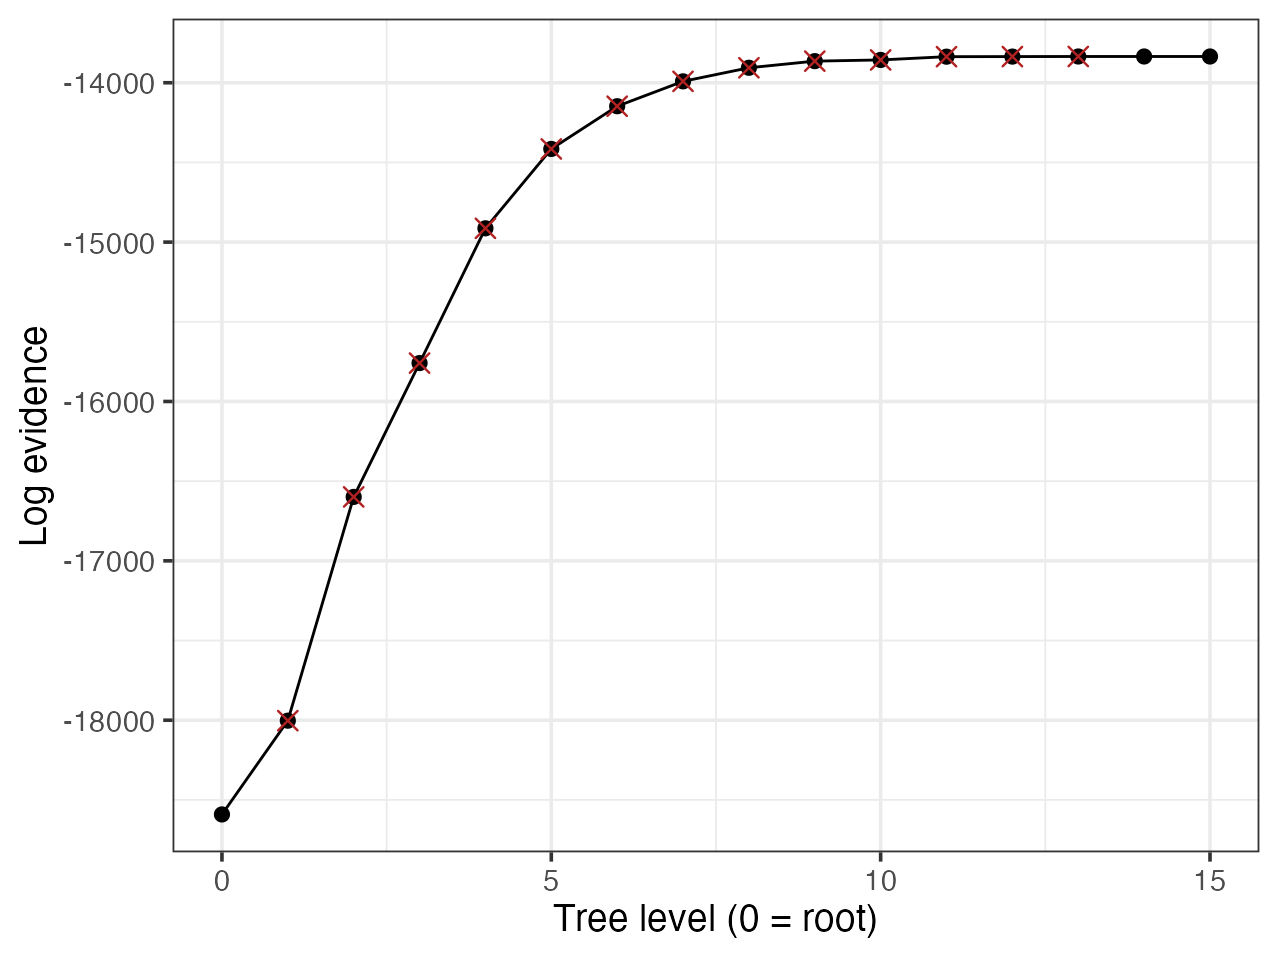

[1] 1600


In [14]:
p_logZ <- ggplot(levels, aes(level, logZ)) +
  geom_line(linewidth = 0.5) +
  geom_point(size = 2) +
  geom_point(data = events, colour = "firebrick", shape = 4, size = 3) +
  labs(x = "Tree level (0 = root)", y = "Log evidence") +
  theme_bw(base_size = 14)
print(p_logZ)

# Export the combined SMC figure.
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(smc_figure_file, p_ess + p_logZ, width = 8, height = 4)

print(levels$ess[levels$level == 0])


### SMC with d=10

In [15]:
smc_n <- 10000
smc_d <- 10
smc_seed_offset <- 10000
smc_figure_file <- file.path(figure_dir, paste0("SMC_diagnostics_n10k_d", smc_d, ".pdf"))

input_dir <- file.path(output_dir,
                       sprintf("n%d_d%d", smc_n, smc_d), "WN")
saved <- readRDS(file.path(input_dir, "result.rds"))
dat <- readRDS(file.path(input_dir, "data.rds"))
settings <- saved$settings
parameters <- saved$diagnostics$theta


In [16]:
X <- dat$X
y <- dat$y - saved$y_center

theta <- restree_theta(
  sig2   = parameters$sig2,
  range  = parameters$range,
  nugget = parameters$nugget,
  nu     = parameters$nu,
  family = parameters$family,
  form   = parameters$form
)

model <- restree_model(
  X, y,
  depth = settings$depth,
  r = settings$r,
  leaf_model = "WN",
  design = saved$diagnostics$design,
  cut_method = "uniform",
  prior_rho = settings$prior_rho,
  prior_beta = settings$prior_beta,
  seed = settings$seed 
)


In [17]:
  fit_d10 <- restree_fit(
    model, theta, method = "smc",
    seed = settings$seed+32, nparticles=1600,
    resampling = "stratified", temper_alpha = 0.1
  )


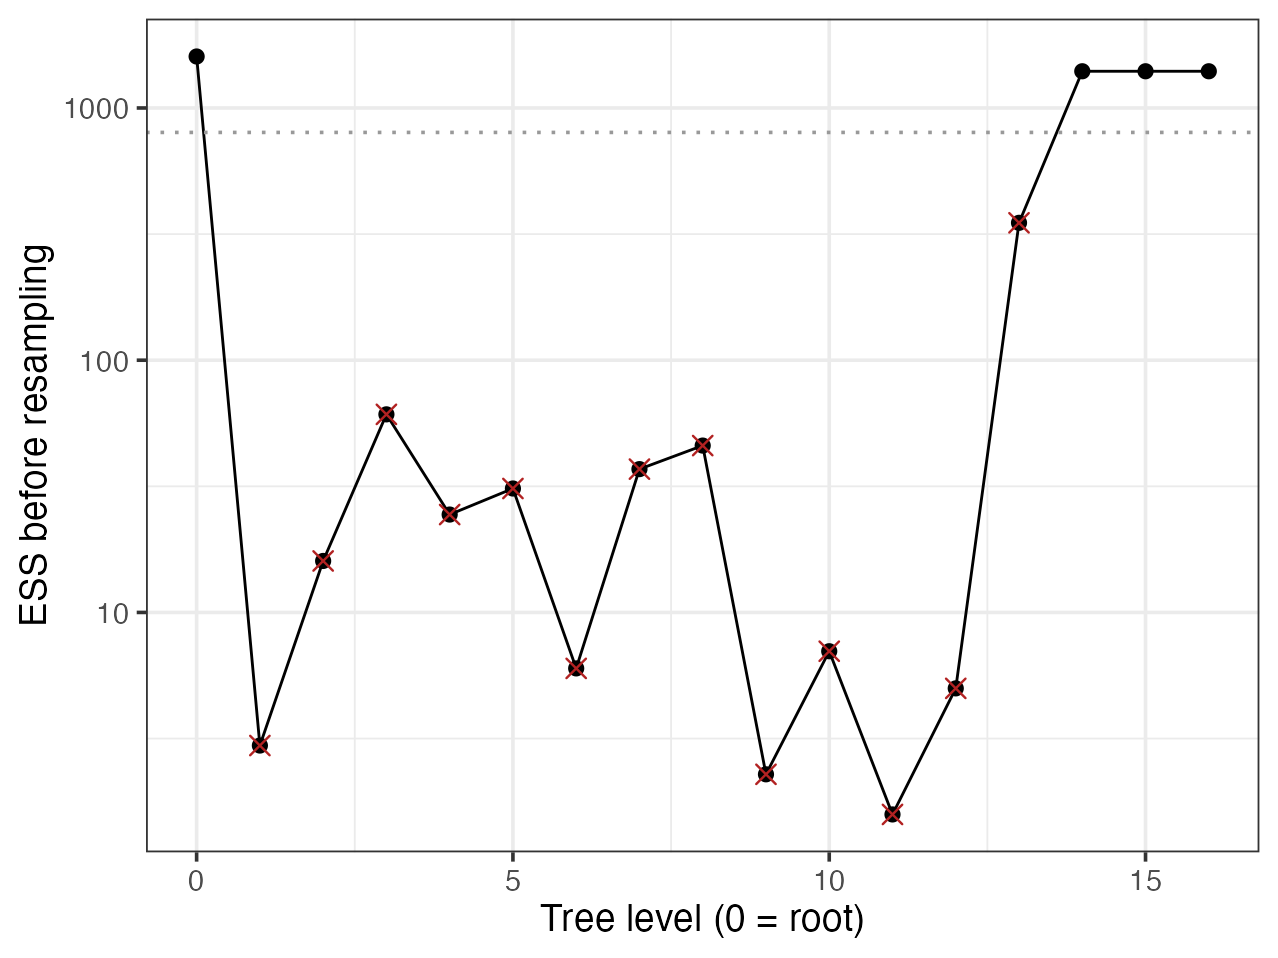

In [18]:
fit = fit_d10
trace <- restree_diagnostics(fit, type = "trace")
levels <- trace$levels
levels$logZ <- as.numeric(fit$fit$Phi0) + cumsum(levels$logZ_increment)
events <- subset(levels, resampled == 1)

p_ess <- ggplot(levels, aes(level, ess)) +
  geom_line(linewidth = 0.5) +
  geom_point(size = 2) +
  geom_point(data = events, colour = "firebrick", shape = 4, size = 3) +
  geom_hline(yintercept = fit$nparticles / 2,
             colour = "grey60", linetype = "dotted") +
  scale_y_log10() +
  labs(x = "Tree level (0 = root)", y = "ESS before resampling") +
  theme_bw(base_size = 14)
print(p_ess)


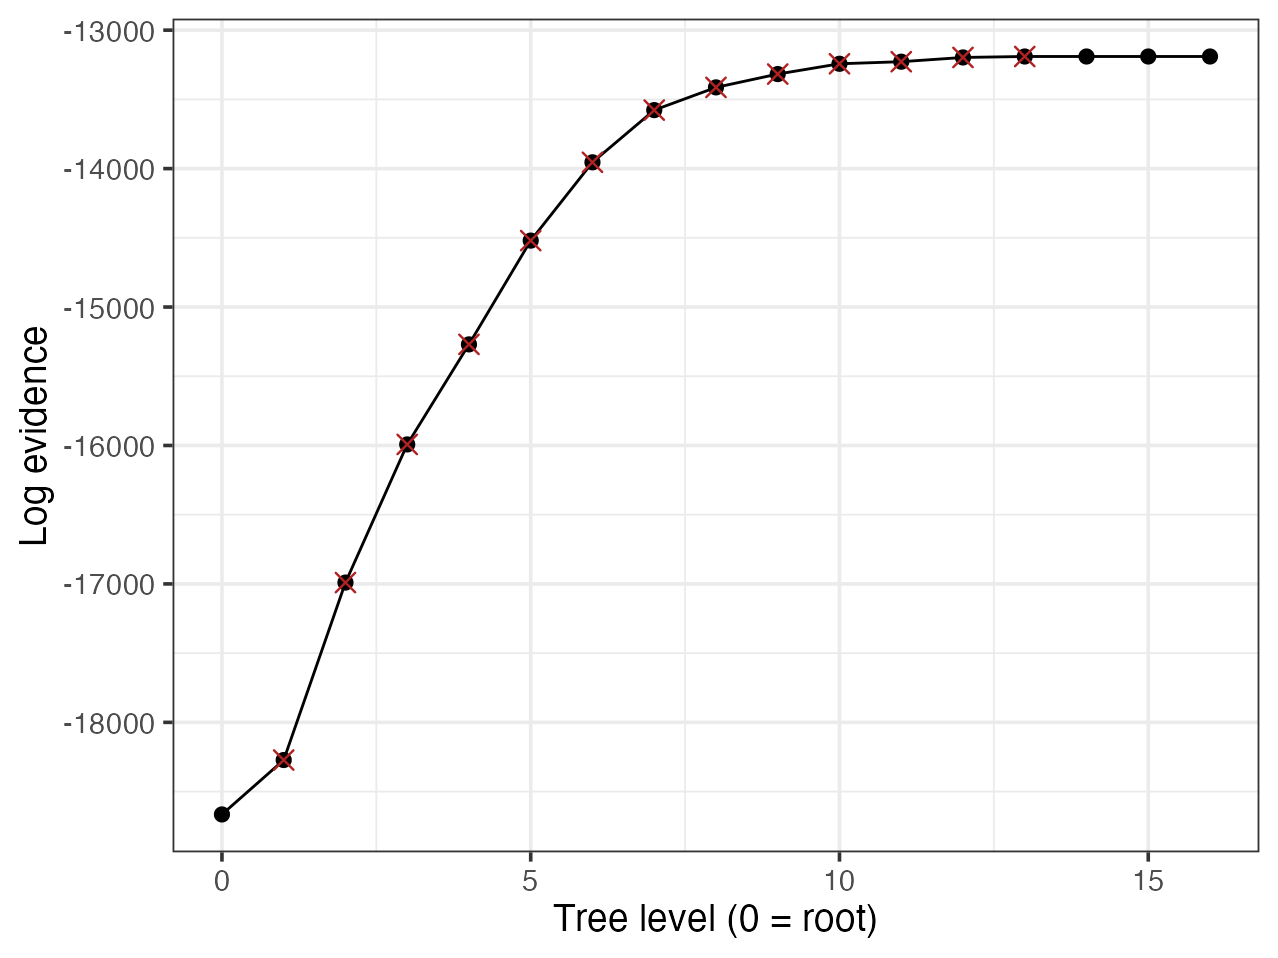

[1] 1600


In [19]:
p_logZ <- ggplot(levels, aes(level, logZ)) +
  geom_line(linewidth = 0.5) +
  geom_point(size = 2) +
  geom_point(data = events, colour = "firebrick", shape = 4, size = 3) +
  labs(x = "Tree level (0 = root)", y = "Log evidence") +
  theme_bw(base_size = 14)
print(p_logZ)

# Export the combined SMC figure.
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(smc_figure_file, p_ess + p_logZ, width = 8, height = 4)

print(levels$ess[levels$level == 0])


# Multiple SMC runs for diagnostics

## SMC with d=10

In [ ]:
# Load the saved d=10 data and parameter estimates.
folder_d10 <- file.path(output_dir, "n10000_d10", "WN")
saved_d10 <- readRDS(file.path(folder_d10, "result.rds"))
dat_d10 <- readRDS(file.path(folder_d10, "data.rds"))

settings_d10 <- saved_d10$settings
parameters_d10 <- saved_d10$diagnostics$theta

theta_d10 <- restree_theta(
  sig2 = parameters_d10$sig2,
  range = parameters_d10$range,
  nugget = parameters_d10$nugget,
  nu = parameters_d10$nu,
  family = parameters_d10$family,
  form = parameters_d10$form
)

model_d10 <- restree_model(
  dat_d10$X,
  dat_d10$y - saved_d10$y_center,
  depth = settings_d10$depth,
  r = settings_d10$r,
  leaf_model = "WN",
  design = saved_d10$diagnostics$design,
  cut_method = "uniform",
  prior_rho = settings_d10$prior_rho,
  prior_beta = settings_d10$prior_beta,
  seed = settings_d10$seed
)

# Keep the model fixed and change only the SMC seed.
nrep <- 15
seed_offsets_d10 <- c(32, 1:14)
seeds_d10 <- settings_d10$seed + seed_offsets_d10
smc_fits_d10 <- vector("list", nrep)
traces_d10 <- vector("list", nrep)


for (i in seq_len(nrep)) {
  message("d=10: run ", i, "/", nrep, "; seed = ", seeds_d10[i])

  fit <- restree_fit(
    model_d10, theta_d10,
    method = "smc",
    seed = seeds_d10[i],
    nparticles = 1600,
    resampling = "stratified",
    temper_alpha = 0.1,
    ncores = 1
  )

  smc_fits_d10[[i]] <- fit

  z <- restree_diagnostics(fit, type = "trace")$levels
  z$logZ <- as.numeric(fit$fit$Phi0) + cumsum(z$logZ_increment)
  z$run <- paste("Run", i)
  z$seed <- seeds_d10[i]
  traces_d10[[i]] <- z
}

levels_d10 <- do.call(rbind, traces_d10)
levels_d10$run <- factor(levels_d10$run, levels = paste("Run", seq_len(nrep)))
events_d10 <- subset(levels_d10, resampled == 1)


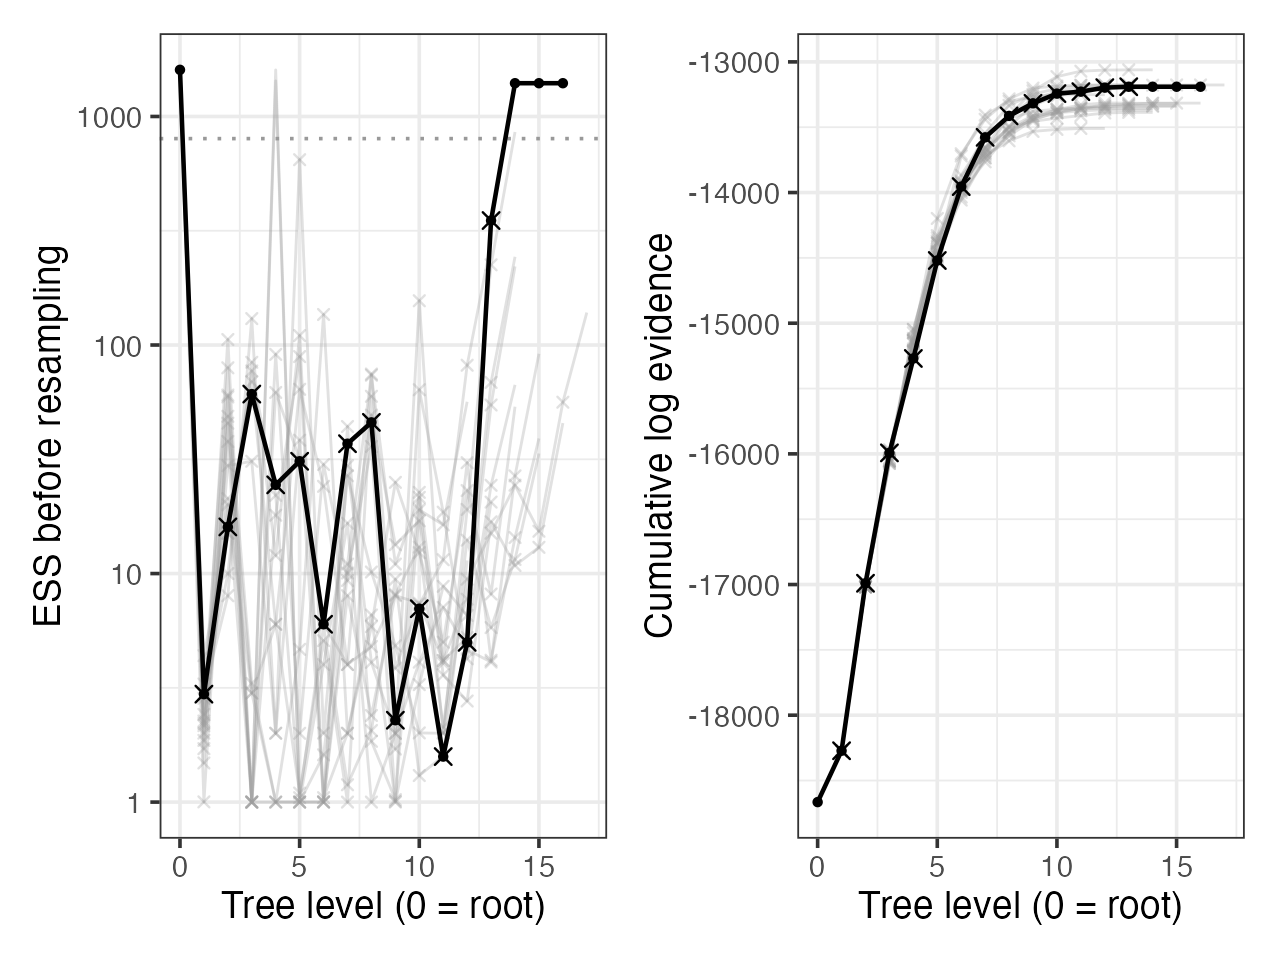

In [26]:
first_d10 <- subset(levels_d10, run == "Run 1")
events_d10 <- subset(levels_d10, resampled == 1)

# Grey curves first, then highlight Run 1 in black.
smc_layers <- list(
  geom_line(colour = "grey60", alpha = 0.3, linewidth = 0.5),
  geom_point(data = events_d10, colour = "grey60",
             alpha = 0.3, shape = 4, size = 1.5),
  geom_line(data = first_d10, colour = "black", linewidth = 0.8),
  geom_point(data = first_d10, colour = "black", size = 1),
  geom_point(data = subset(first_d10, resampled == 1),
             colour = "black", shape = 4, size = 2.5),
  theme_bw(base_size = 14)
)

# ESS.
p_ess_d10 <- ggplot(levels_d10, aes(level, ess, group = run)) +
  geom_hline(yintercept = 800, colour = "grey60", linetype = "dotted") +
  smc_layers +
  scale_y_log10() +
  labs(x = "Tree level (0 = root)", y = "ESS before resampling")

# Cumulative log evidence.
p_logZ_d10 <- ggplot(levels_d10, aes(level, logZ, group = run)) +
  smc_layers +
  labs(x = "Tree level (0 = root)", y = "Cumulative log evidence")

p_smc_d10 <- p_ess_d10 + p_logZ_d10
print(p_smc_d10)

In [28]:
dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(
  file.path(figure_dir, "SMC_multiple_runs_n10k_d10.pdf"),
  p_smc_d10, width = 12, height = 5
)

## SMC with d=20

In [29]:
# Load the saved d=20 data and parameter estimates.
folder_d20 <- file.path(output_dir, "n10000_d20", "WN")
saved_d20 <- readRDS(file.path(folder_d20, "result.rds"))
dat_d20 <- readRDS(file.path(folder_d20, "data.rds"))

settings_d20 <- saved_d20$settings
parameters_d20 <- saved_d20$diagnostics$theta

theta_d20 <- restree_theta(
  sig2 = parameters_d20$sig2,
  range = parameters_d20$range,
  nugget = parameters_d20$nugget,
  nu = parameters_d20$nu,
  family = parameters_d20$family,
  form = parameters_d20$form
)

model_d20 <- restree_model(
  dat_d20$X,
  dat_d20$y - saved_d20$y_center,
  depth = settings_d20$depth,
  r = settings_d20$r,
  leaf_model = "WN",
  design = saved_d20$diagnostics$design,
  cut_method = "uniform",
  prior_rho = settings_d20$prior_rho,
  prior_beta = settings_d20$prior_beta,
  seed = settings_d20$seed
)

# Keep the model fixed and change only the SMC seed.
nrep <- 15
seed_offsets_d20 <- c(24, 1:14)
seeds_d20 <- settings_d20$seed + seed_offsets_d20

smc_fits_d20 <- vector("list", nrep)
traces_d20 <- vector("list", nrep)

for (i in seq_len(nrep)) {
  message("d=20: run ", i, "/", nrep, "; seed = ", seeds_d20[i])

  fit <- restree_fit(
    model_d20, theta_d20,
    method = "smc",
    seed = seeds_d20[i],
    nparticles = 1600,
    resampling = "stratified",
    temper_alpha = 0.1,
    ncores = 1
  )

  smc_fits_d20[[i]] <- fit

  z <- restree_diagnostics(fit, type = "trace")$levels
  z$logZ <- as.numeric(fit$fit$Phi0) + cumsum(z$logZ_increment)
  z$run <- paste("Run", i)
  z$seed <- seeds_d20[i]
  traces_d20[[i]] <- z
}

levels_d20 <- do.call(rbind, traces_d20)
levels_d20$run <- factor(levels_d20$run, levels = paste("Run", seq_len(nrep)))
events_d20 <- subset(levels_d20, resampled == 1)



d=20: run 1/15; seed = 20290947
d=20: run 2/15; seed = 20290924
d=20: run 3/15; seed = 20290925
d=20: run 4/15; seed = 20290926
d=20: run 5/15; seed = 20290927
d=20: run 6/15; seed = 20290928
d=20: run 7/15; seed = 20290929
d=20: run 8/15; seed = 20290930
d=20: run 9/15; seed = 20290931
d=20: run 10/15; seed = 20290932
d=20: run 11/15; seed = 20290933
d=20: run 12/15; seed = 20290934
d=20: run 13/15; seed = 20290935
d=20: run 14/15; seed = 20290936
d=20: run 15/15; seed = 20290937


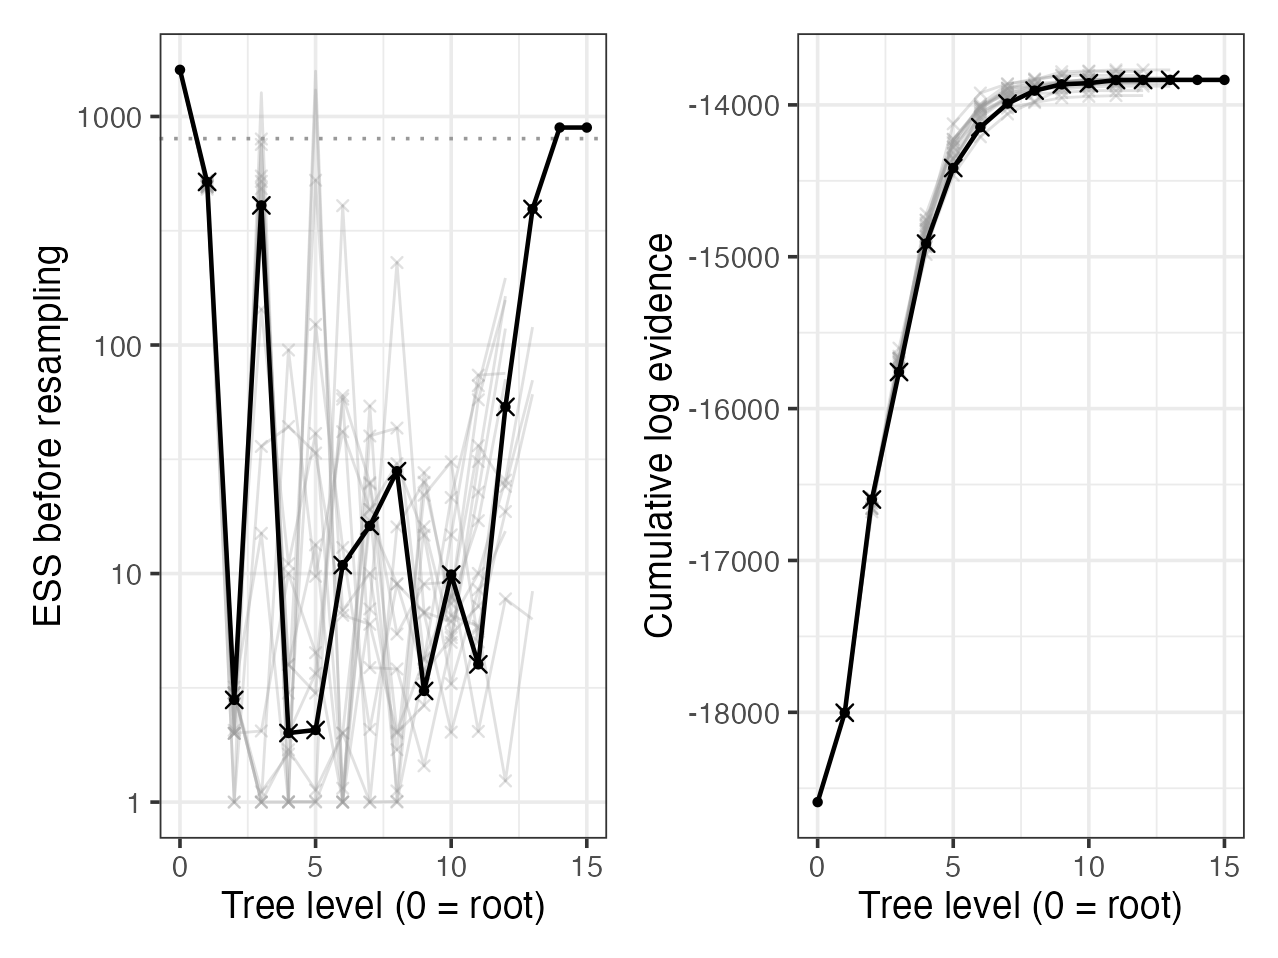

In [31]:
first_d20 <- subset(levels_d20, run == "Run 1")
events_d20 <- subset(levels_d20, resampled == 1)

# Grey curves first, then highlight Run 1 in black.
smc_layers_d20 <- list(
  geom_line(colour = "grey60", alpha = 0.3, linewidth = 0.5),
  geom_point(data = events_d20, colour = "grey60",
             alpha = 0.3, shape = 4, size = 1.5),
  geom_line(data = first_d20, colour = "black", linewidth = 0.8),
  geom_point(data = first_d20, colour = "black", size = 1),
  geom_point(data = subset(first_d20, resampled == 1),
             colour = "black", shape = 4, size = 2.5),
  theme_bw(base_size = 14)
)

# ESS.
p_ess_d20 <- ggplot(levels_d20, aes(level, ess, group = run)) +
  geom_hline(yintercept = 800, colour = "grey60", linetype = "dotted") +
  smc_layers_d20 +
  scale_y_log10() +
  labs(x = "Tree level (0 = root)", y = "ESS before resampling")

# Cumulative log evidence.
p_logZ_d20 <- ggplot(levels_d20, aes(level, logZ, group = run)) +
  smc_layers_d20 +
  labs(x = "Tree level (0 = root)", y = "Cumulative log evidence")

p_smc_d20 <- p_ess_d20 + p_logZ_d20
print(p_smc_d20)


dir.create(figure_dir, recursive = TRUE, showWarnings = FALSE)
ggsave(
  file.path(figure_dir, "SMC_multiple_runs_n10k_d20.pdf"),
  p_smc_d20, width = 12, height = 5
)
